# Deep Learning-Based Classification of Imbalanced Wireless Capsule Endoscopy (WCE) Datasets

**Objective:** To design, train, and evaluate deep learning models for gastrointestinal disease classification using imbalanced WCE datasets, while applying under-sampling, data augmentation-based over-sampling, transfer learning, and intelligent learning rate control.

In [ ]:
import os
import tarfile
import glob
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define paths
DRIVE_DATA_DIR = '/content/drive/MyDrive/kvasir-capsule-labeled-images/labelled_images'
LOCAL_DATA_DIR = '/content/kvasir_dataset'

# Create local directory for fast I/O
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

# Extract tar.gz files
for item in os.listdir(DRIVE_DATA_DIR):
    if item.endswith('.tar.gz'):
        file_path = os.path.join(DRIVE_DATA_DIR, item)
        class_name = item.replace('.tar.gz', '')
        extract_path = os.path.join(LOCAL_DATA_DIR, class_name)

        if not os.path.exists(extract_path):
            os.makedirs(extract_path, exist_ok=True)
            with tarfile.open(file_path, 'r:gz') as tar:
                tar.extractall(path=extract_path)

print("Extraction complete. Data ready at:", LOCAL_DATA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extraction complete. Data ready at: /content/kvasir_dataset


## Task 1: Dataset Exploration and Imbalance Analysis

/tmp/ipykernel_4327/2646449900.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=df_counts, palette='viridis')


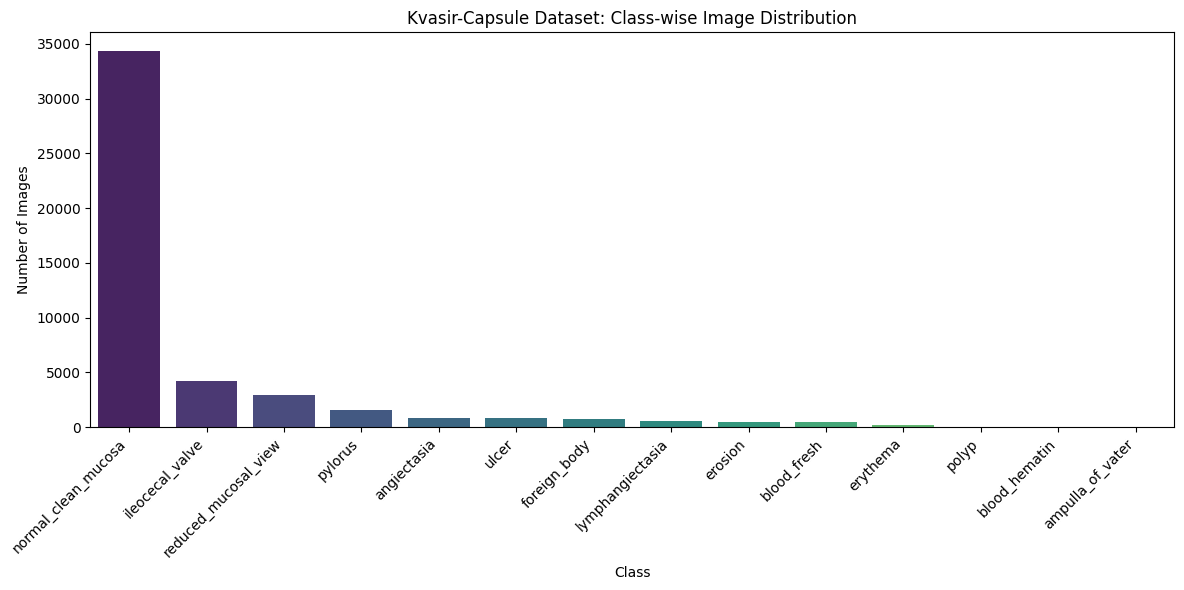

--- Majority Classes ---
               Class  Count
 normal_clean_mucosa  34338
     ileocecal_valve   4189
reduced_mucosal_view   2906

--- Minority Classes ---
           Class  Count
           polyp     55
   blood_hematin     12
ampulla_of_vater     10


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Gather all image paths recursively to handle nested folders
all_images = []
for root, dirs, files in os.walk(LOCAL_DATA_DIR):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            # The class name is the top-level folder inside LOCAL_DATA_DIR
            rel_path = os.path.relpath(root, LOCAL_DATA_DIR)
            top_level_class = rel_path.split(os.sep)[0]
            all_images.append({'filepath': os.path.join(root, file), 'class': top_level_class})

df_all = pd.DataFrame(all_images)
df_counts = df_all['class'].value_counts().reset_index()
df_counts.columns = ['Class', 'Count']

# Plot class-wise image distribution [cite: 21, 25]
plt.figure(figsize=(12, 6))
sns.barplot(x='Class', y='Count', data=df_counts, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Kvasir-Capsule Dataset: Class-wise Image Distribution')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

# Identify majority and minority classes [cite: 22]
print("--- Majority Classes ---")
print(df_counts.head(3).to_string(index=False))
print("\n--- Minority Classes ---")
print(df_counts.tail(3).to_string(index=False))

**Discussion: Criticality of Class Imbalance in Medical Diagnosis**
Class imbalance causes neural networks to optimize for overall accuracy by heavily favoring majority classes (normal tissue). This results in a high false-negative rate for rare, severe conditions (minority classes). In WCE screening, missing a disease is a critical failure, making dataset balance essential to force the model to learn features of rare anomalies rather than exploiting class distributions.

## Task 2: Under-Sampling (Majority Class Control)
Apply random under-sampling to reduce majority classes to a fixed threshold (200 images) while maintaining all minority class samples.

/tmp/ipykernel_4327/2007584645.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_under = df_all.groupby('class').apply(
/tmp/ipykernel_4327/2007584645.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_under, x='class', palette='magma', order=df_under['class'].value_counts().index)


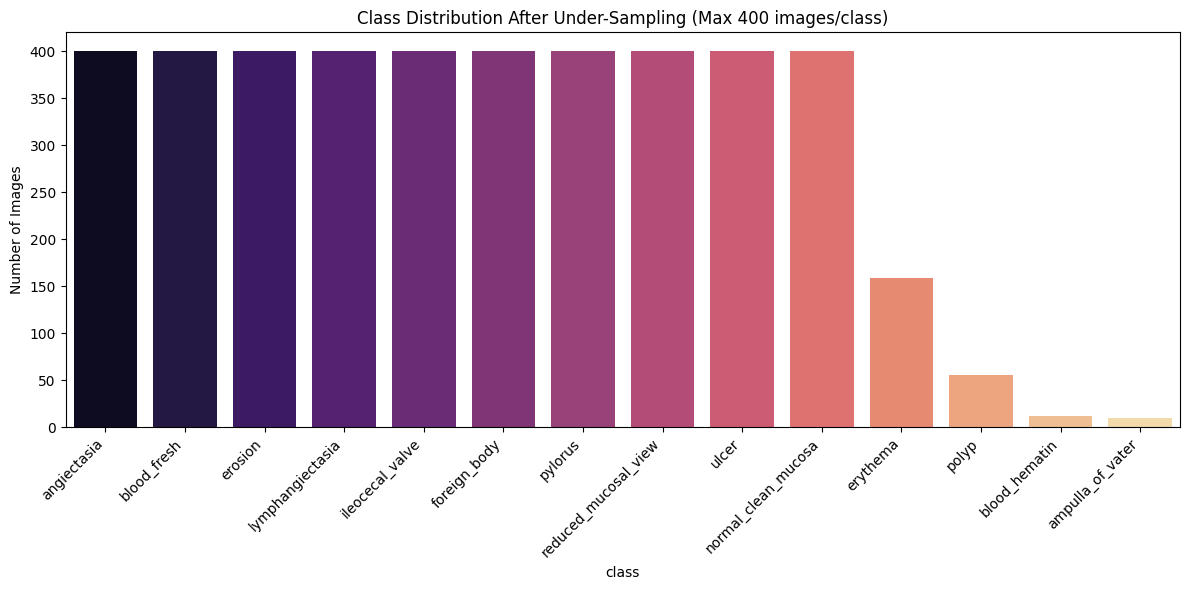

Original Dataset Size: 47238
Under-sampled Dataset Size: 4236


In [ ]:
THRESHOLD = 400

# Apply random under-sampling
df_under = df_all.groupby('class').apply(
    lambda x: x.sample(n=min(len(x), THRESHOLD), random_state=42)
).reset_index(drop=True)

# Plot updated distribution [cite: 35]
plt.figure(figsize=(12, 6))
sns.countplot(data=df_under, x='class', palette='magma', order=df_under['class'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title(f'Class Distribution After Under-Sampling (Max {THRESHOLD} images/class)')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

print(f"Original Dataset Size: {len(df_all)}")
print(f"Under-sampled Dataset Size: {len(df_under)}")

**Observation on data loss vs balance:**
Capping classes at 400 images successfully removes target bias, forcing the model to weigh all conditions equally. However, this causes massive data loss for majority classes, discarding structural variations of normal mucosa. The model risks overfitting on the small subset of retained healthy images due to the lack of diverse training examples.

## Task 3: Data Augmentation-Based Over-Sampling
Apply augmentations (flip, rotation, shifts, zoom) exclusively to minority classes to increase their sample size up to the threshold of 400.

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)

BALANCED_DIR = '/content/balanced_dataset'
os.makedirs(BALANCED_DIR, exist_ok=True)

# Balance the dataset by augmenting minority classes
for cls in df_under['class'].unique():
    cls_save_dir = os.path.join(BALANCED_DIR, cls)
    os.makedirs(cls_save_dir, exist_ok=True)

    class_images = df_under[df_under['class'] == cls]['filepath'].tolist()
    current_count = len(class_images)

    # Copy existing images
    for img_path in class_images:
        img_name = os.path.basename(img_path)
        new_path = os.path.join(cls_save_dir, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            cv2.imwrite(new_path, img)

    # Augment to reach threshold
    if current_count < THRESHOLD:
        needed = THRESHOLD - current_count
        for i in range(needed):
            src_path = np.random.choice(class_images)
            img = load_img(src_path)
            x = img_to_array(img)
            x = x.reshape((1,) + x.shape)

            for batch in datagen.flow(x, batch_size=1, save_to_dir=cls_save_dir, save_prefix='aug', save_format='jpg'):
                break

# Re-build final dataframe
final_data = []
for root, dirs, files in os.walk(BALANCED_DIR):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            cls = os.path.basename(root)
            final_data.append({'filepath': os.path.join(root, file), 'class': cls})

df_balanced = pd.DataFrame(final_data)

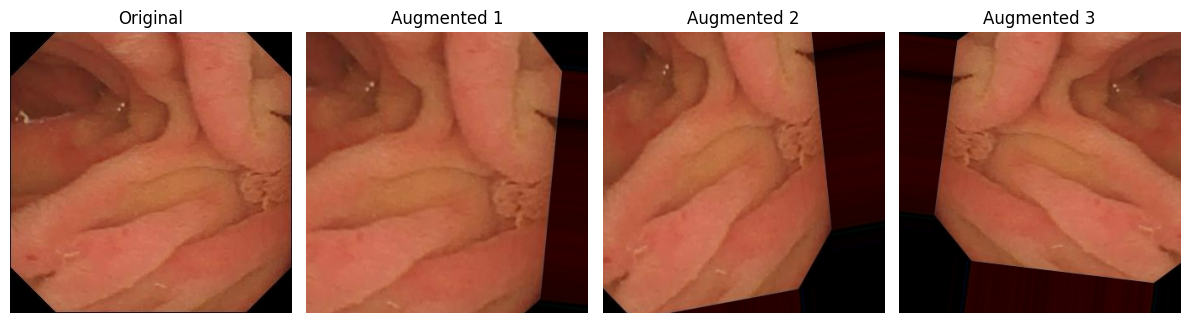

--- Updated Dataset Size Summary ---
Total images: 5573
class
pylorus                 400
erosion                 400
normal_clean_mucosa     400
foreign_body            400
lymphangiectasia        400
ileocecal_valve         400
reduced_mucosal_view    400
blood_fresh             400
angiectasia             400
ulcer                   400
erythema                398
ampulla_of_vater        394
blood_hematin           392
polyp                   389
Name: count, dtype: int64


In [ ]:
# Deliverable: Before/after augmentation sample images
minority_cls = df_counts.tail(1)['Class'].values[0]
sample_img_path = df_all[df_all['class'] == minority_cls]['filepath'].iloc[0]

img = load_img(sample_img_path)
x = img_to_array(img)
x = x.reshape((1,) + x.shape)
aug_iter = datagen.flow(x, batch_size=1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

for i in range(3):
    batch = next(aug_iter)
    plt.subplot(1, 4, i+2)
    plt.imshow(batch[0].astype('uint8'))
    plt.title(f"Augmented {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Deliverable: Updated dataset size summary
print("--- Updated Dataset Size Summary ---")
print(f"Total images: {len(df_balanced)}")
print(df_balanced['class'].value_counts())

## Task 4: Data Pre-Processing
In this step, the balanced dataset is split into training (70%), validation (15%), and testing (15%) sets. The images are resized to 224x224 and pixel values are normalized to a range of.

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df_balanced, test_size=0.30, random_state=42, stratify=df_balanced['class'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['class'])

print(f"Train set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

Train set size: 3901
Validation set size: 836
Test set size: 836


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='class',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='class',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='class',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3901 validated image filenames belonging to 14 classes.
Found 836 validated image filenames belonging to 14 classes.
Found 836 validated image filenames belonging to 14 classes.


## Task 5: Model Design Using Transfer Learning
In this section, we design three different deep learning architectures using transfer learning. We selected **MobileNet**, **ResNet101V2**, and **EfficientNetB0** for comparison.

For each model, we:
1. Load the ImageNet-pretrained weights.
2. Freeze the early layers (the base model) to retain generic feature extraction capabilities.
3. Replace the top classification head.
4. Apply Dropout (to prevent overfitting) and L2 Regularization on the final Dense layer.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import MobileNet, ResNet101V2, EfficientNetB0

# Determine number of classes from our dataframe
NUM_CLASSES = len(train_df['class'].unique())
IMG_SHAPE = (224, 224, 3)

def build_transfer_model(base_model_class, model_name):
    # 1. Load ImageNet-pretrained model (excluding the top classification layers)
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=IMG_SHAPE)

    # 2. Freeze early layers (we freeze the entire base model to act as a feature extractor)
    base_model.trainable = False

    # 3. Replace final classification layer
    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    # 4. Apply dropout + L2 regularization
    x = Dropout(0.5)(x) # 50% Dropout
    predictions = Dense(NUM_CLASSES,
                        activation='softmax',
                        kernel_regularizer=l2(0.01), # L2 Regularization
                        name='final_classification')(x)

    # Construct the final model
    model = Model(inputs=base_model.input, outputs=predictions, name=model_name)

    return model

# Initialize the three chosen models
model_mobilenet = build_transfer_model(MobileNet, "MobileNet_Transfer")
model_resnet = build_transfer_model(ResNet101V2, "ResNet101V2_Transfer")
model_efficientnet = build_transfer_model(EfficientNetB0, "EfficientNetB0_Transfer")

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
171317808/171317808 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# Function to print the required deliverables (Summary & Parameter counts)
def print_model_stats(model):
    print(f"================ {model.name} ================")
    # Deliverable: Model summary
    model.summary()

    # Deliverable: Number of trainable vs frozen parameters
    trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    frozen_params = sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])
    total_params = trainable_params + frozen_params

    print(f"\n[{model.name}] Parameter Breakdown:")
    print(f" - Total Parameters:    {total_params:,}")
    print(f" - Frozen Parameters:   {frozen_params:,} (Base Model)")
    print(f" - Trainable Parameters:{trainable_params:,} (Classification Head)\n")

# Output the stats for all three models
print_model_stats(model_mobilenet)
print_model_stats(model_resnet)
print_model_stats(model_efficientnet)

================ MobileNet_Transfer ================


Model: "MobileNet_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,243,214 (12.37 MB)

 Trainable params: 14,350 (56.05 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,067,505 (15.52 MB)

 Trainable params: 17,934 (70.05 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


[EfficientNetB0_Transfer] Parameter Breakdown:
 - Total Parameters:    4,067,505.0
 - Frozen Parameters:   4,049,571.0 (Base Model)
 - Trainable Parameters:17,934 (Classification Head)



### Deliverable: Comparative Study Between Three Models
Based on the architecture and parameter counts, here is a theoretical comparison of our three chosen models before training:

1. **MobileNet:** * **Architecture:** Utilizes depthwise separable convolutions to drastically reduce the number of parameters and computational cost.
   * **Parameters:** It has the lowest parameter count among the three (approx. 3.2M frozen).
   * **Pros/Cons:** Extremely fast to train and lightweight, but might struggle to capture the highly complex, subtle textures of gastrointestinal diseases compared to deeper networks.

2. **ResNet101V2:**
   * **Architecture:** A very deep network (101 layers) that uses residual connections (skip connections) to solve the vanishing gradient problem, allowing it to learn highly complex features.
   * **Parameters:** Extremely heavy (approx. 42.6M frozen parameters).
   * **Pros/Cons:** Acts as a powerful feature extractor for medical imaging, but will be the slowest to train and requires significant memory.

3. **EfficientNetB0:**
   * **Architecture:** Uses a compound scaling method that uniformly scales network width, depth, and resolution for optimal performance.
   * **Parameters:** Highly efficient, sitting between MobileNet and ResNet in terms of size (approx. 4M frozen parameters).
   * **Pros/Cons:** Offers state-of-the-art accuracy while maintaining computational efficiency. It is often the best balance between the speed of MobileNet and the accuracy of deep ResNets.

## Task 6: Intelligent Learning Rate Control
To ensure the model converges efficiently without overshooting the local minima, we will implement an adaptive learning rate control. Specifically, we will use **ReduceLROnPlateau**, which monitors the validation loss and reduces the learning rate by a certain factor if the loss fails to improve for a set number of epochs (patience).

We will also define a custom callback to track the learning rate at each epoch and a plotting function. The actual plots (Deliverables for Task 6) will be generated immediately after we train the models in Task 7.

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, Callback
import tensorflow.keras.backend as K

# 1. Implement ReduceLROnPlateau
lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,        # Wait 3 epochs before reducing
    verbose=1,
    factor=0.5,        # Halve the learning rate
    min_lr=1e-6        # Lower bound for learning rate
)

# Optional but highly recommended: Early Stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

# 2. Custom Callback to explicitly track Learning Rate per epoch
class LRTracker(Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        # Get the current learning rate from the optimizer
        lr = float(K.get_value(self.model.optimizer.learning_rate))
        logs['lr'] = lr

# Combine callbacks into a list to pass to the model's fit() function
callbacks_list = [lr_reduction, early_stopping, LRTracker()]

# 3. Define the plotting function (Task 6 Deliverables)
def plot_training_curves(history, title_suffix=""):
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(15, 5))

    # Deliverable: Training vs validation loss curves
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss', marker='o')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o')
    plt.title(f'Loss Curves {title_suffix}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Deliverable: Learning rate vs epoch plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['lr'], label='Learning Rate', color='green', marker='o')
    plt.title(f'Learning Rate over Epochs {title_suffix}')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print("Callbacks and plotting functions initialized.")

Callbacks and plotting functions initialized.


## Data Preparation for Task 7
To train the models under the three distinct settings, we must create separate train, validation, and test splits (70/15/15) and data generators for the original imbalanced dataset and the under-sampled dataset.

In [ ]:
# Split Setting 1: Original Imbalanced Dataset (df_all)
train_all, temp_all = train_test_split(df_all, test_size=0.30, random_state=42, stratify=df_all['class'])
val_all, test_all = train_test_split(temp_all, test_size=0.50, random_state=42, stratify=temp_all['class'])

# Split Setting 2: Under-sampled Dataset (df_under)
train_under, temp_under = train_test_split(df_under, test_size=0.30, random_state=42, stratify=df_under['class'])
val_under, test_under = train_test_split(temp_under, test_size=0.50, random_state=42, stratify=temp_under['class'])

# Setting 3: Balanced Dataset (df_balanced) was already split in Task 4 into train_df, val_df, test_df

# Create Generators for Setting 1
train_gen_all = datagen.flow_from_dataframe(train_all, x_col='filepath', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True)
val_gen_all = datagen.flow_from_dataframe(val_all, x_col='filepath', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen_all = datagen.flow_from_dataframe(test_all, x_col='filepath', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# Create Generators for Setting 2
train_gen_under = datagen.flow_from_dataframe(train_under, x_col='filepath', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True)
val_gen_under = datagen.flow_from_dataframe(val_under, x_col='filepath', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen_under = datagen.flow_from_dataframe(test_under, x_col='filepath', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# Map the settings for easy iteration during training
dataset_settings = {
    "1_Imbalanced": (train_gen_all, val_gen_all, test_gen_all),
    "2_Undersampled_Only": (train_gen_under, val_gen_under, test_gen_under),
    "3_Undersampled_Plus_Aug": (train_generator, val_generator, test_generator) # From Task 4
}

Found 33066 validated image filenames belonging to 14 classes.
Found 7086 validated image filenames belonging to 14 classes.
Found 7086 validated image filenames belonging to 14 classes.
Found 2965 validated image filenames belonging to 14 classes.
Found 635 validated image filenames belonging to 14 classes.
Found 636 validated image filenames belonging to 14 classes.


## Task 7: Model Training
We will now compile and train all three models (MobileNet, ResNet101V2, EfficientNetB0) across all three dataset settings. We will store the training histories to plot the required learning rate and loss curves (Deliverables for Task 6) immediately after each model finishes training.


Starting Training: MobileNet_1_Imbalanced
Epoch 1/20
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 103s 84ms/step - accuracy: 0.7753 - loss: 0.9077 - val_accuracy: 0.8356 - val_loss: 0.6158 - learning_rate: 0.0010 - lr: 0.0010
Epoch 2/20
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 66s 64ms/step - accuracy: 0.8169 - loss: 0.6905 - val_accuracy: 0.8421 - val_loss: 0.6018 - learning_rate: 0.0010 - lr: 0.0010
Epoch 3/20
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 63s 61ms/step - accuracy: 0.8180 - loss: 0.6928 - val_accuracy: 0.8290 - val_loss: 0.6096 - learning_rate: 0.0010 - lr: 0.0010
Epoch 4/20
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 65s 63ms/step - accuracy: 0.8196 - loss: 0.6888 - val_accuracy: 0.8497 - val_loss: 0.6004 - learning_rate: 0.0010 - lr: 0.0010
Epoch 5/20
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 63s 60ms/step - accuracy: 0.8185 - loss: 0.6885 - val_accuracy: 0.8288 - val_loss: 0.6251 - learning_rate: 0.0010 - lr: 0.0010
Epoch 6/20
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 64s 62ms/step - accuracy: 0.8186 - loss: 0.6851 - val_accuracy: 0.821

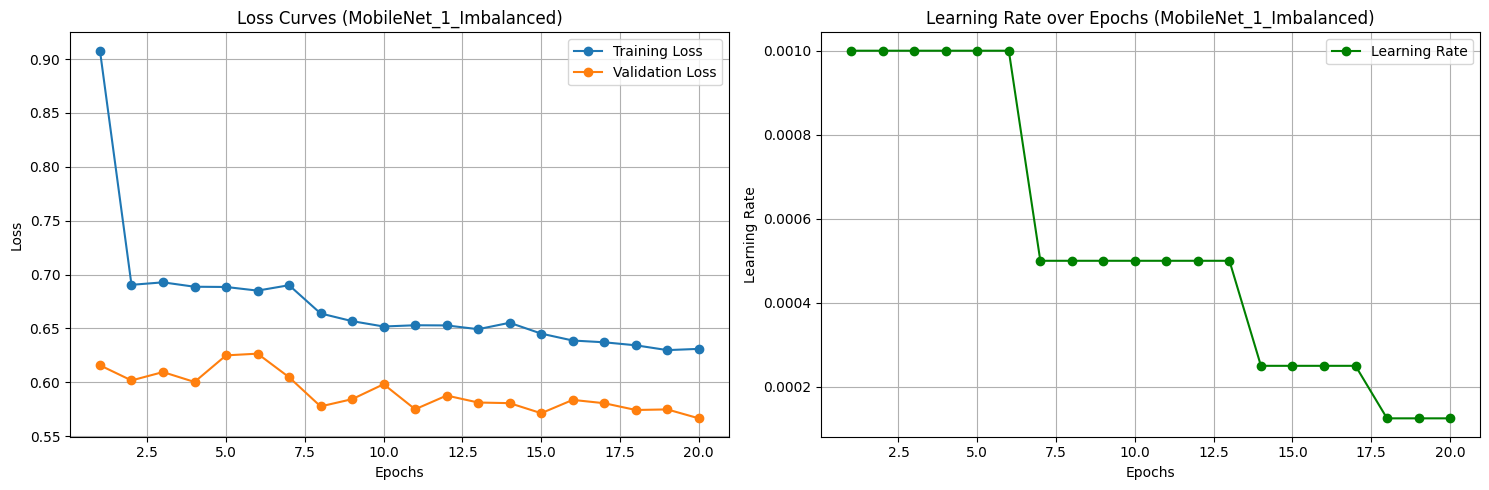


Starting Training: MobileNet_2_Undersampled_Only
Epoch 1/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 34s 308ms/step - accuracy: 0.2546 - loss: 2.6309 - val_accuracy: 0.5260 - val_loss: 1.6922 - learning_rate: 0.0010 - lr: 0.0010
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.4921 - loss: 1.7507 - val_accuracy: 0.6157 - val_loss: 1.3949 - learning_rate: 0.0010 - lr: 0.0010
Epoch 3/20
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5636 - loss: 1.5097
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.5825 - loss: 1.4566 - val_accuracy: 0.6472 - val_loss: 1.2475 - learning_rate: 0.0010 - lr: 5.0000e-04
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.6314 - loss: 1.3197 - val_accuracy: 0.6819 - val_loss: 1.2111 - learning_rate: 5.0000e-04 - lr: 5.0000e-04
Epoch 5/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.6617 - loss: 1.2568 - val_accuracy: 0.6882 - val_loss: 1.1603 - l

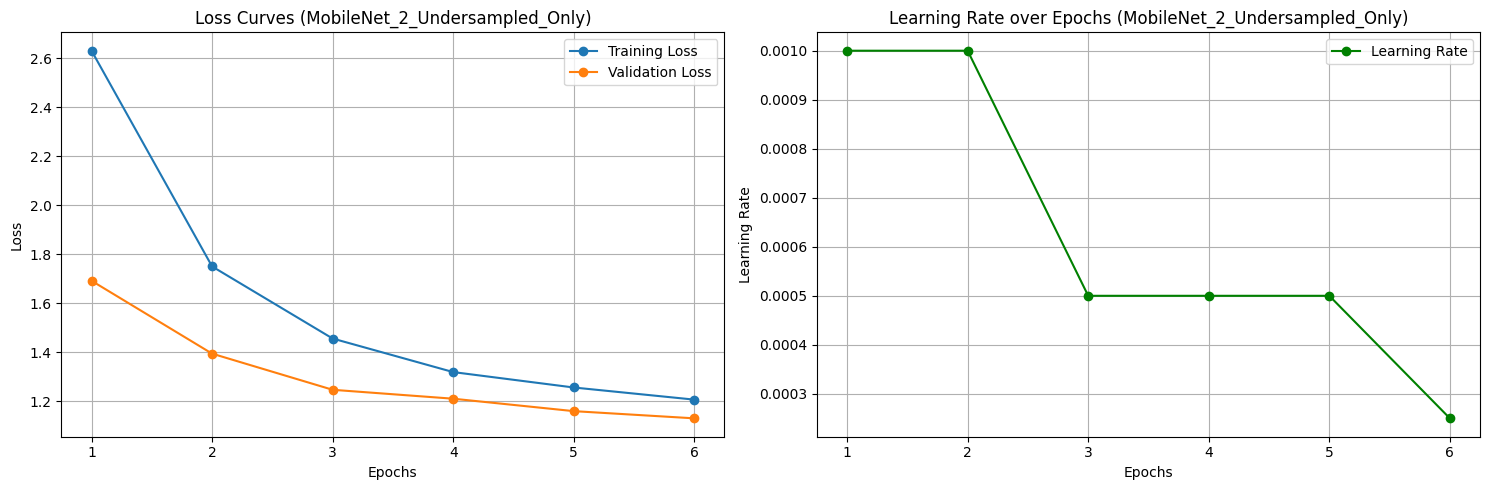


Starting Training: MobileNet_3_Undersampled_Plus_Aug
Epoch 1/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 36s 251ms/step - accuracy: 0.3609 - loss: 2.3990 - val_accuracy: 0.6866 - val_loss: 1.3161 - learning_rate: 0.0010 - lr: 0.0010
Epoch 2/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.6024 - loss: 1.4648 - val_accuracy: 0.7572 - val_loss: 1.0753 - learning_rate: 0.0010 - lr: 0.0010
Epoch 3/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6695 - loss: 1.2355
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
122/122 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.6796 - loss: 1.2037 - val_accuracy: 0.7978 - val_loss: 0.9524 - learning_rate: 0.0010 - lr: 5.0000e-04
Epoch 4/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.7196 - loss: 1.0846 - val_accuracy: 0.7919 - val_loss: 0.9232 - learning_rate: 5.0000e-04 - lr: 5.0000e-04
Epoch 5/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.7360 - loss: 1.0351 - val_accuracy: 0.8110 - val_

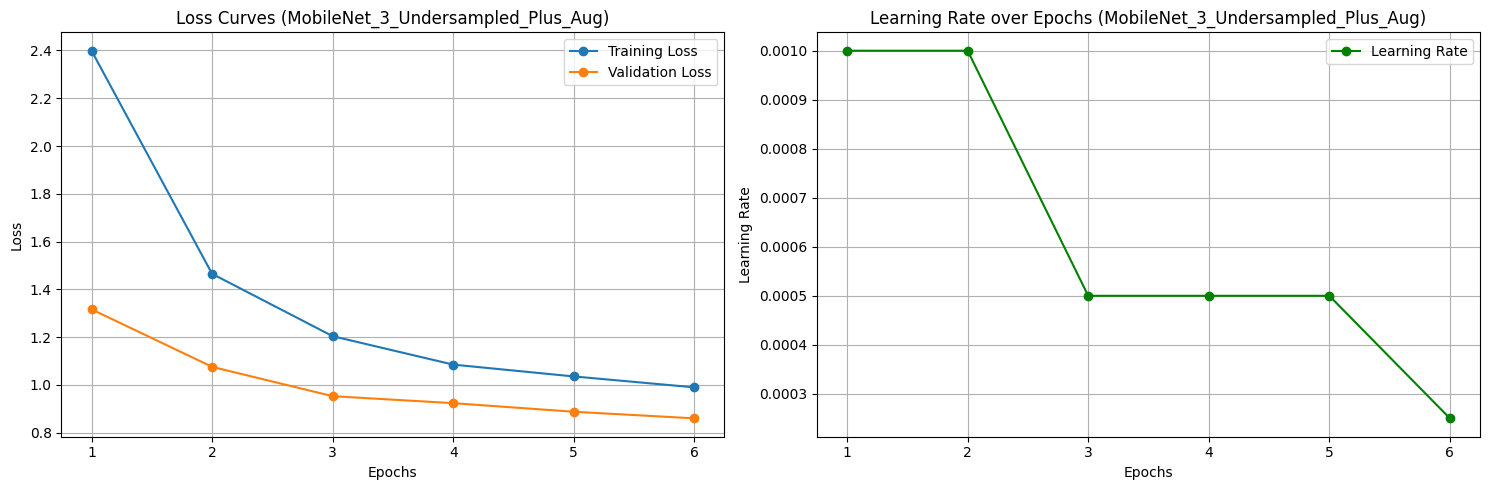


Starting Training: ResNet101V2_1_Imbalanced
Epoch 1/20
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 227s 199ms/step - accuracy: 0.7949 - loss: 0.8060 - val_accuracy: 0.8446 - val_loss: 0.5884 - learning_rate: 0.0010 - lr: 0.0010
Epoch 2/20
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 186s 180ms/step - accuracy: 0.8289 - loss: 0.6569 - val_accuracy: 0.8621 - val_loss: 0.5509 - learning_rate: 0.0010 - lr: 0.0010
Epoch 3/20
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 185s 179ms/step - accuracy: 0.8314 - loss: 0.6537 - val_accuracy: 0.8459 - val_loss: 0.5869 - learning_rate: 0.0010 - lr: 0.0010
Epoch 4/20
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 185s 179ms/step - accuracy: 0.8307 - loss: 0.6548 - val_accuracy: 0.8585 - val_loss: 0.5669 - learning_rate: 0.0010 - lr: 0.0010
Epoch 5/20
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.8331 - loss: 0.6473
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 184s 178ms/step - accuracy: 0.8312 - loss: 0.6526 - val_accuracy: 0.8575 -

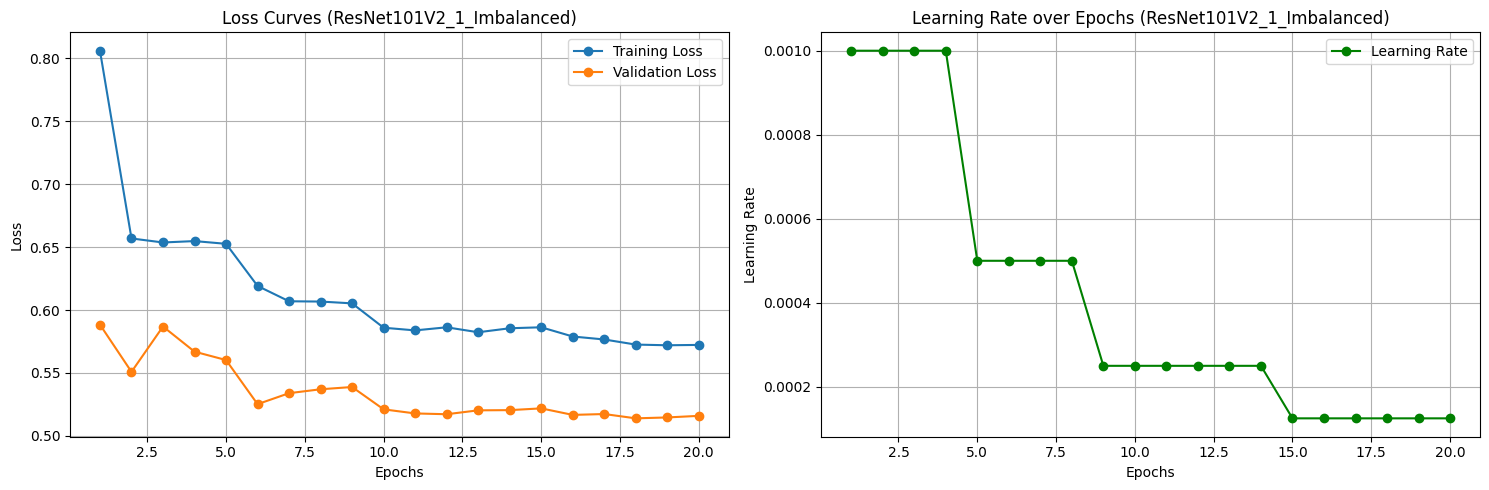


Starting Training: ResNet101V2_2_Undersampled_Only
Epoch 1/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 55s 416ms/step - accuracy: 0.3494 - loss: 2.2964 - val_accuracy: 0.6236 - val_loss: 1.4309 - learning_rate: 0.0010 - lr: 0.0010
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/step - accuracy: 0.5821 - loss: 1.4511 - val_accuracy: 0.6740 - val_loss: 1.2177 - learning_rate: 0.0010 - lr: 0.0010
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.6421 - loss: 1.2463
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
93/93 ━━━━━━━━━━━━━━━━━━━━ 19s 205ms/step - accuracy: 0.6509 - loss: 1.2207 - val_accuracy: 0.7307 - val_loss: 1.1098 - learning_rate: 0.0010 - lr: 5.0000e-04
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 16s 176ms/step - accuracy: 0.7245 - loss: 1.0569 - val_accuracy: 0.7433 - val_loss: 1.0532 - learning_rate: 5.0000e-04 - lr: 5.0000e-04
Epoch 5/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step - accuracy: 0.7329 - loss: 1.0288 - val_accuracy: 0.7465 - val_loss:

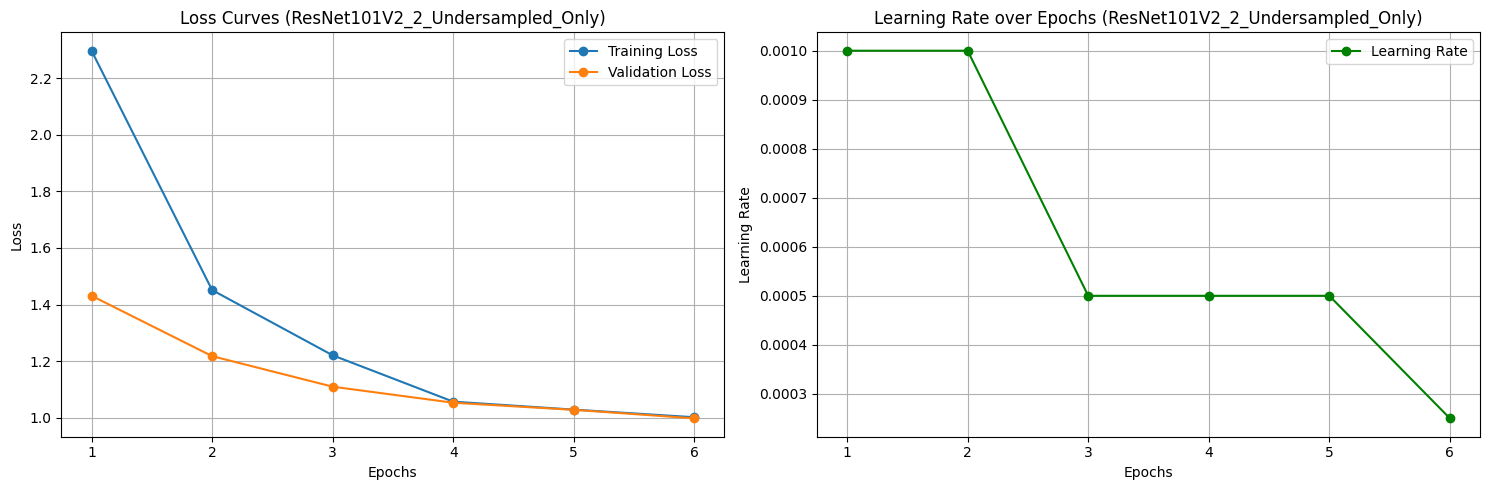


Starting Training: ResNet101V2_3_Undersampled_Plus_Aug
Epoch 1/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 60s 355ms/step - accuracy: 0.4512 - loss: 2.0010 - val_accuracy: 0.7321 - val_loss: 1.1251 - learning_rate: 0.0010 - lr: 0.0010
Epoch 2/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 24s 194ms/step - accuracy: 0.6816 - loss: 1.1962 - val_accuracy: 0.7883 - val_loss: 0.9385 - learning_rate: 0.0010 - lr: 0.0010
Epoch 3/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.7349 - loss: 1.0472
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
122/122 ━━━━━━━━━━━━━━━━━━━━ 22s 180ms/step - accuracy: 0.7470 - loss: 1.0141 - val_accuracy: 0.7978 - val_loss: 0.8479 - learning_rate: 0.0010 - lr: 5.0000e-04
Epoch 4/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 22s 181ms/step - accuracy: 0.7803 - loss: 0.9027 - val_accuracy: 0.8170 - val_loss: 0.8042 - learning_rate: 5.0000e-04 - lr: 5.0000e-04
Epoch 5/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 22s 182ms/step - accuracy: 0.7926 - loss: 0.8690 - val_accuracy: 0.

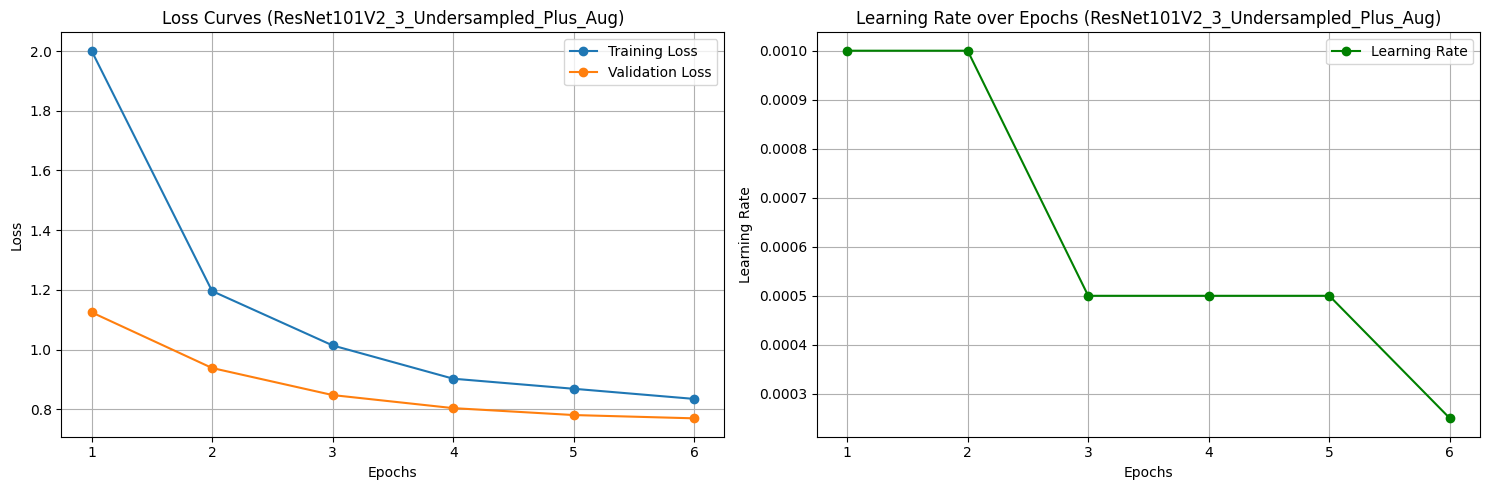


Starting Training: EfficientNetB0_1_Imbalanced
Epoch 1/20
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 131s 101ms/step - accuracy: 0.7242 - loss: 1.2156 - val_accuracy: 0.7269 - val_loss: 1.1640 - learning_rate: 0.0010 - lr: 0.0010
Epoch 2/20
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 70s 68ms/step - accuracy: 0.7269 - loss: 1.1598 - val_accuracy: 0.7269 - val_loss: 1.1574 - learning_rate: 0.0010 - lr: 0.0010
Epoch 3/20
1033/1034 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7268 - loss: 1.1564
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 72s 70ms/step - accuracy: 0.7269 - loss: 1.1579 - val_accuracy: 0.7269 - val_loss: 1.1534 - learning_rate: 0.0010 - lr: 5.0000e-04
Epoch 4/20
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 76s 73ms/step - accuracy: 0.7269 - loss: 1.1469 - val_accuracy: 0.7269 - val_loss: 1.1385 - learning_rate: 5.0000e-04 - lr: 5.0000e-04
Epoch 5/20
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 76s 74ms/step - accuracy: 0.7269 - loss: 1.1447 - val_accuracy: 0.

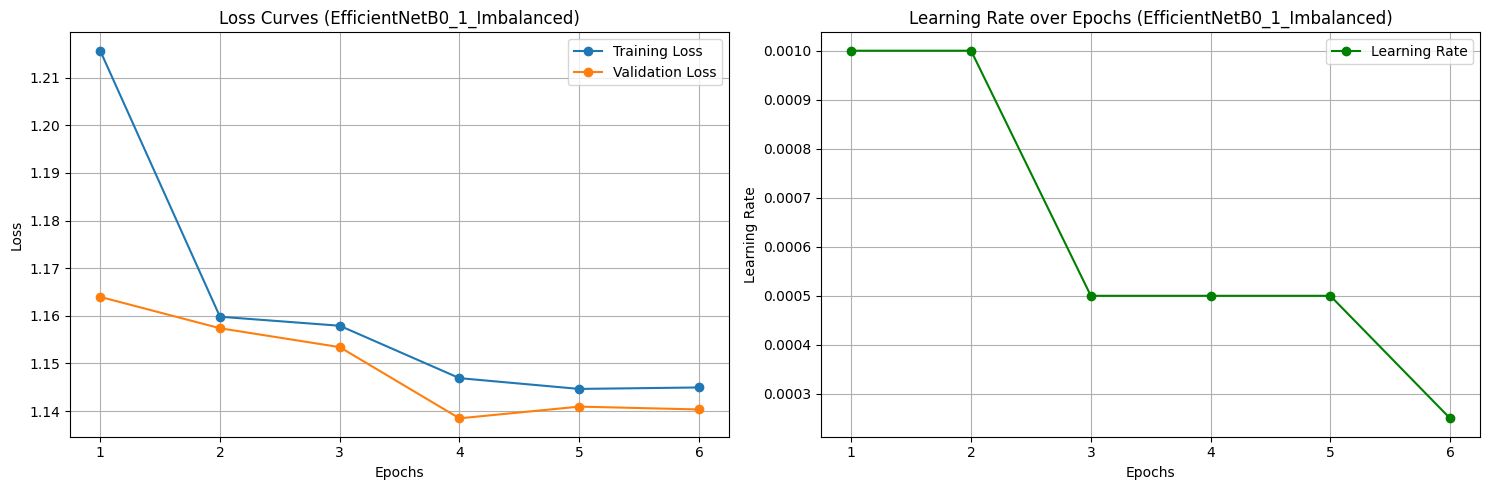


Starting Training: EfficientNetB0_2_Undersampled_Only
Epoch 1/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 61s 445ms/step - accuracy: 0.0971 - loss: 2.7211 - val_accuracy: 0.0945 - val_loss: 2.6247 - learning_rate: 0.0010 - lr: 0.0010
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.0894 - loss: 2.6307 - val_accuracy: 0.0945 - val_loss: 2.5604 - learning_rate: 0.0010 - lr: 0.0010
Epoch 3/20
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.0864 - loss: 2.5680
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.0904 - loss: 2.5713 - val_accuracy: 0.0945 - val_loss: 2.5290 - learning_rate: 0.0010 - lr: 5.0000e-04
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.0894 - loss: 2.5388 - val_accuracy: 0.0945 - val_loss: 2.5166 - learning_rate: 5.0000e-04 - lr: 5.0000e-04
Epoch 5/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.0992 - loss: 2.5314 - val_accuracy: 0.0945 - val_loss: 2.505

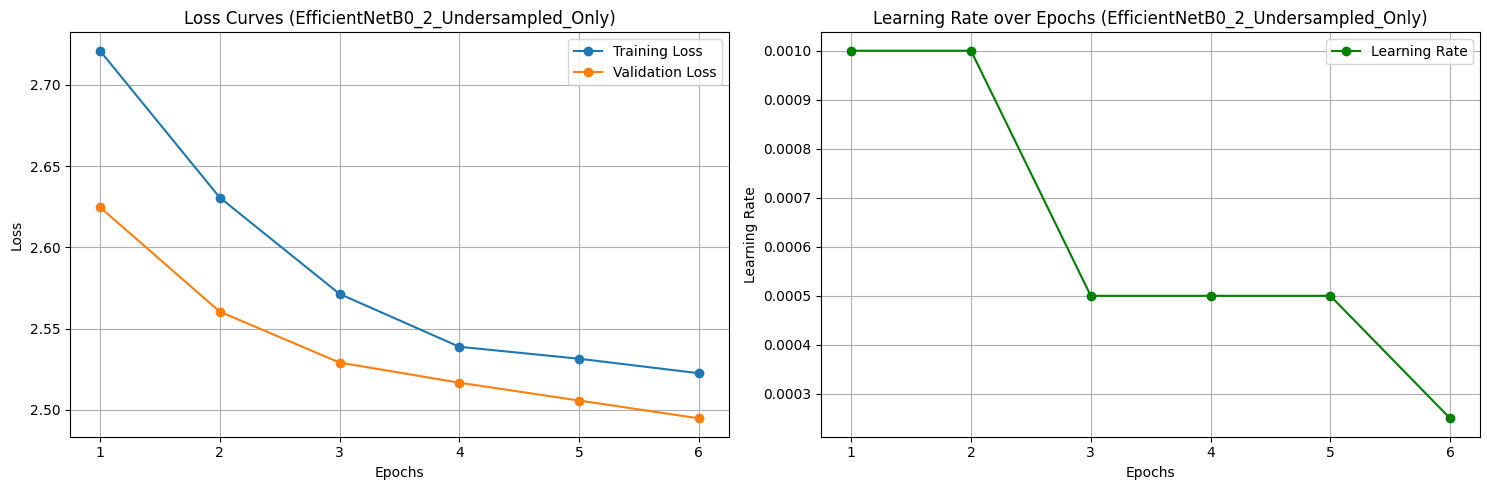


Starting Training: EfficientNetB0_3_Undersampled_Plus_Aug
Epoch 1/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 64s 364ms/step - accuracy: 0.0687 - loss: 2.9058 - val_accuracy: 0.0718 - val_loss: 2.8046 - learning_rate: 0.0010 - lr: 0.0010
Epoch 2/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.0751 - loss: 2.7987 - val_accuracy: 0.0706 - val_loss: 2.7699 - learning_rate: 0.0010 - lr: 0.0010
Epoch 3/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.0736 - loss: 2.7646
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.0725 - loss: 2.7614 - val_accuracy: 0.0718 - val_loss: 2.7295 - learning_rate: 0.0010 - lr: 5.0000e-04
Epoch 4/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.0695 - loss: 2.7242 - val_accuracy: 0.0718 - val_loss: 2.7009 - learning_rate: 5.0000e-04 - lr: 5.0000e-04
Epoch 5/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.0702 - loss: 2.7140 - val_accuracy: 0.0718

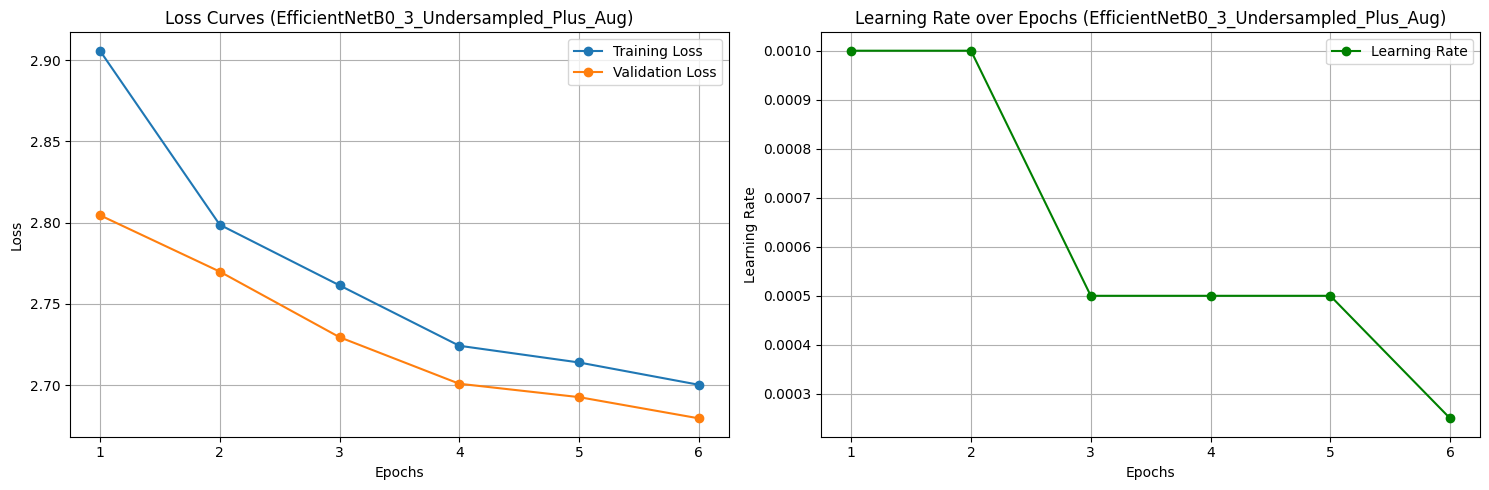


All training configurations complete!


In [ ]:
from tensorflow.keras.optimizers import Adam
import gc

EPOCHS = 20 # Adjust this based on your computational limits
training_histories = {}
trained_models = {}

models_to_train = [
    (MobileNet, 'MobileNet'),
    (ResNet101V2, 'ResNet101V2'),
    (EfficientNetB0, 'EfficientNetB0')
]

for base_model_class, model_name in models_to_train:
    for setting_name, (train_gen, val_gen, test_gen) in dataset_settings.items():
        run_name = f"{model_name}_{setting_name}"
        print(f"\n{'='*50}")
        print(f"Starting Training: {run_name}")
        print(f"{'='*50}")

        # Build a fresh model to ensure weights are reset for each setting
        model = build_transfer_model(base_model_class, run_name)

        # Compile model
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        # Train model
        history = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=EPOCHS,
            callbacks=callbacks_list,
            verbose=1
        )

        # Save history and model
        training_histories[run_name] = history
        trained_models[run_name] = model

        # Task 6 Deliverables: Plot curves for this specific run
        plot_training_curves(history, title_suffix=f"({run_name})")

        # Clear memory
        K.clear_session()
        gc.collect()

print("\nAll training configurations complete!")

## Task 7: Model Evaluation
We evaluate the trained models using Accuracy, Precision, Recall, and F1-score.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = []
confusion_matrices = {}

for model_name, model in trained_models.items():
    if "1_Imbalanced" in model_name:
        test_gen = test_gen_all
    elif "2_Undersampled_Only" in model_name:
        test_gen = test_gen_under
    else:
        test_gen = test_generator

    test_gen.reset()

    y_true = test_gen.classes
    class_labels = list(test_gen.class_indices.keys())

    preds = model.predict(test_gen, steps=len(test_gen), verbose=0)
    y_pred = np.argmax(preds, axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    results.append({
        'Model_Configuration': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    cm = confusion_matrix(y_true, y_pred)
    confusion_matrices[model_name] = (cm, class_labels)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                   Model_Configuration  Accuracy  Precision   Recall  F1-Score
                MobileNet_1_Imbalanced  0.846458   0.719735 0.342458  0.422341
         MobileNet_2_Undersampled_Only  0.544025   0.542791 0.492262  0.489490
     MobileNet_3_Undersampled_Plus_Aug  0.699761   0.707313 0.701190  0.693187
              ResNet101V2_1_Imbalanced  0.861981   0.716639 0.406959  0.485699
       ResNet101V2_2_Undersampled_Only  0.603774   0.548314 0.527976  0.527608
   ResNet101V2_3_Undersampled_Plus_Aug  0.727273   0.734911 0.728530  0.719357
           EfficientNetB0_1_Imbalanced  0.726926   0.051923 0.071429  0.060134
    EfficientNetB0_2_Undersampled_Only  0.094340   0.006739 0.071429  0.012315
EfficientNetB0_3_Undersampled_Plus_Aug  0.071770   0.005126 0.071429  0.009566


## Confusion Matrices

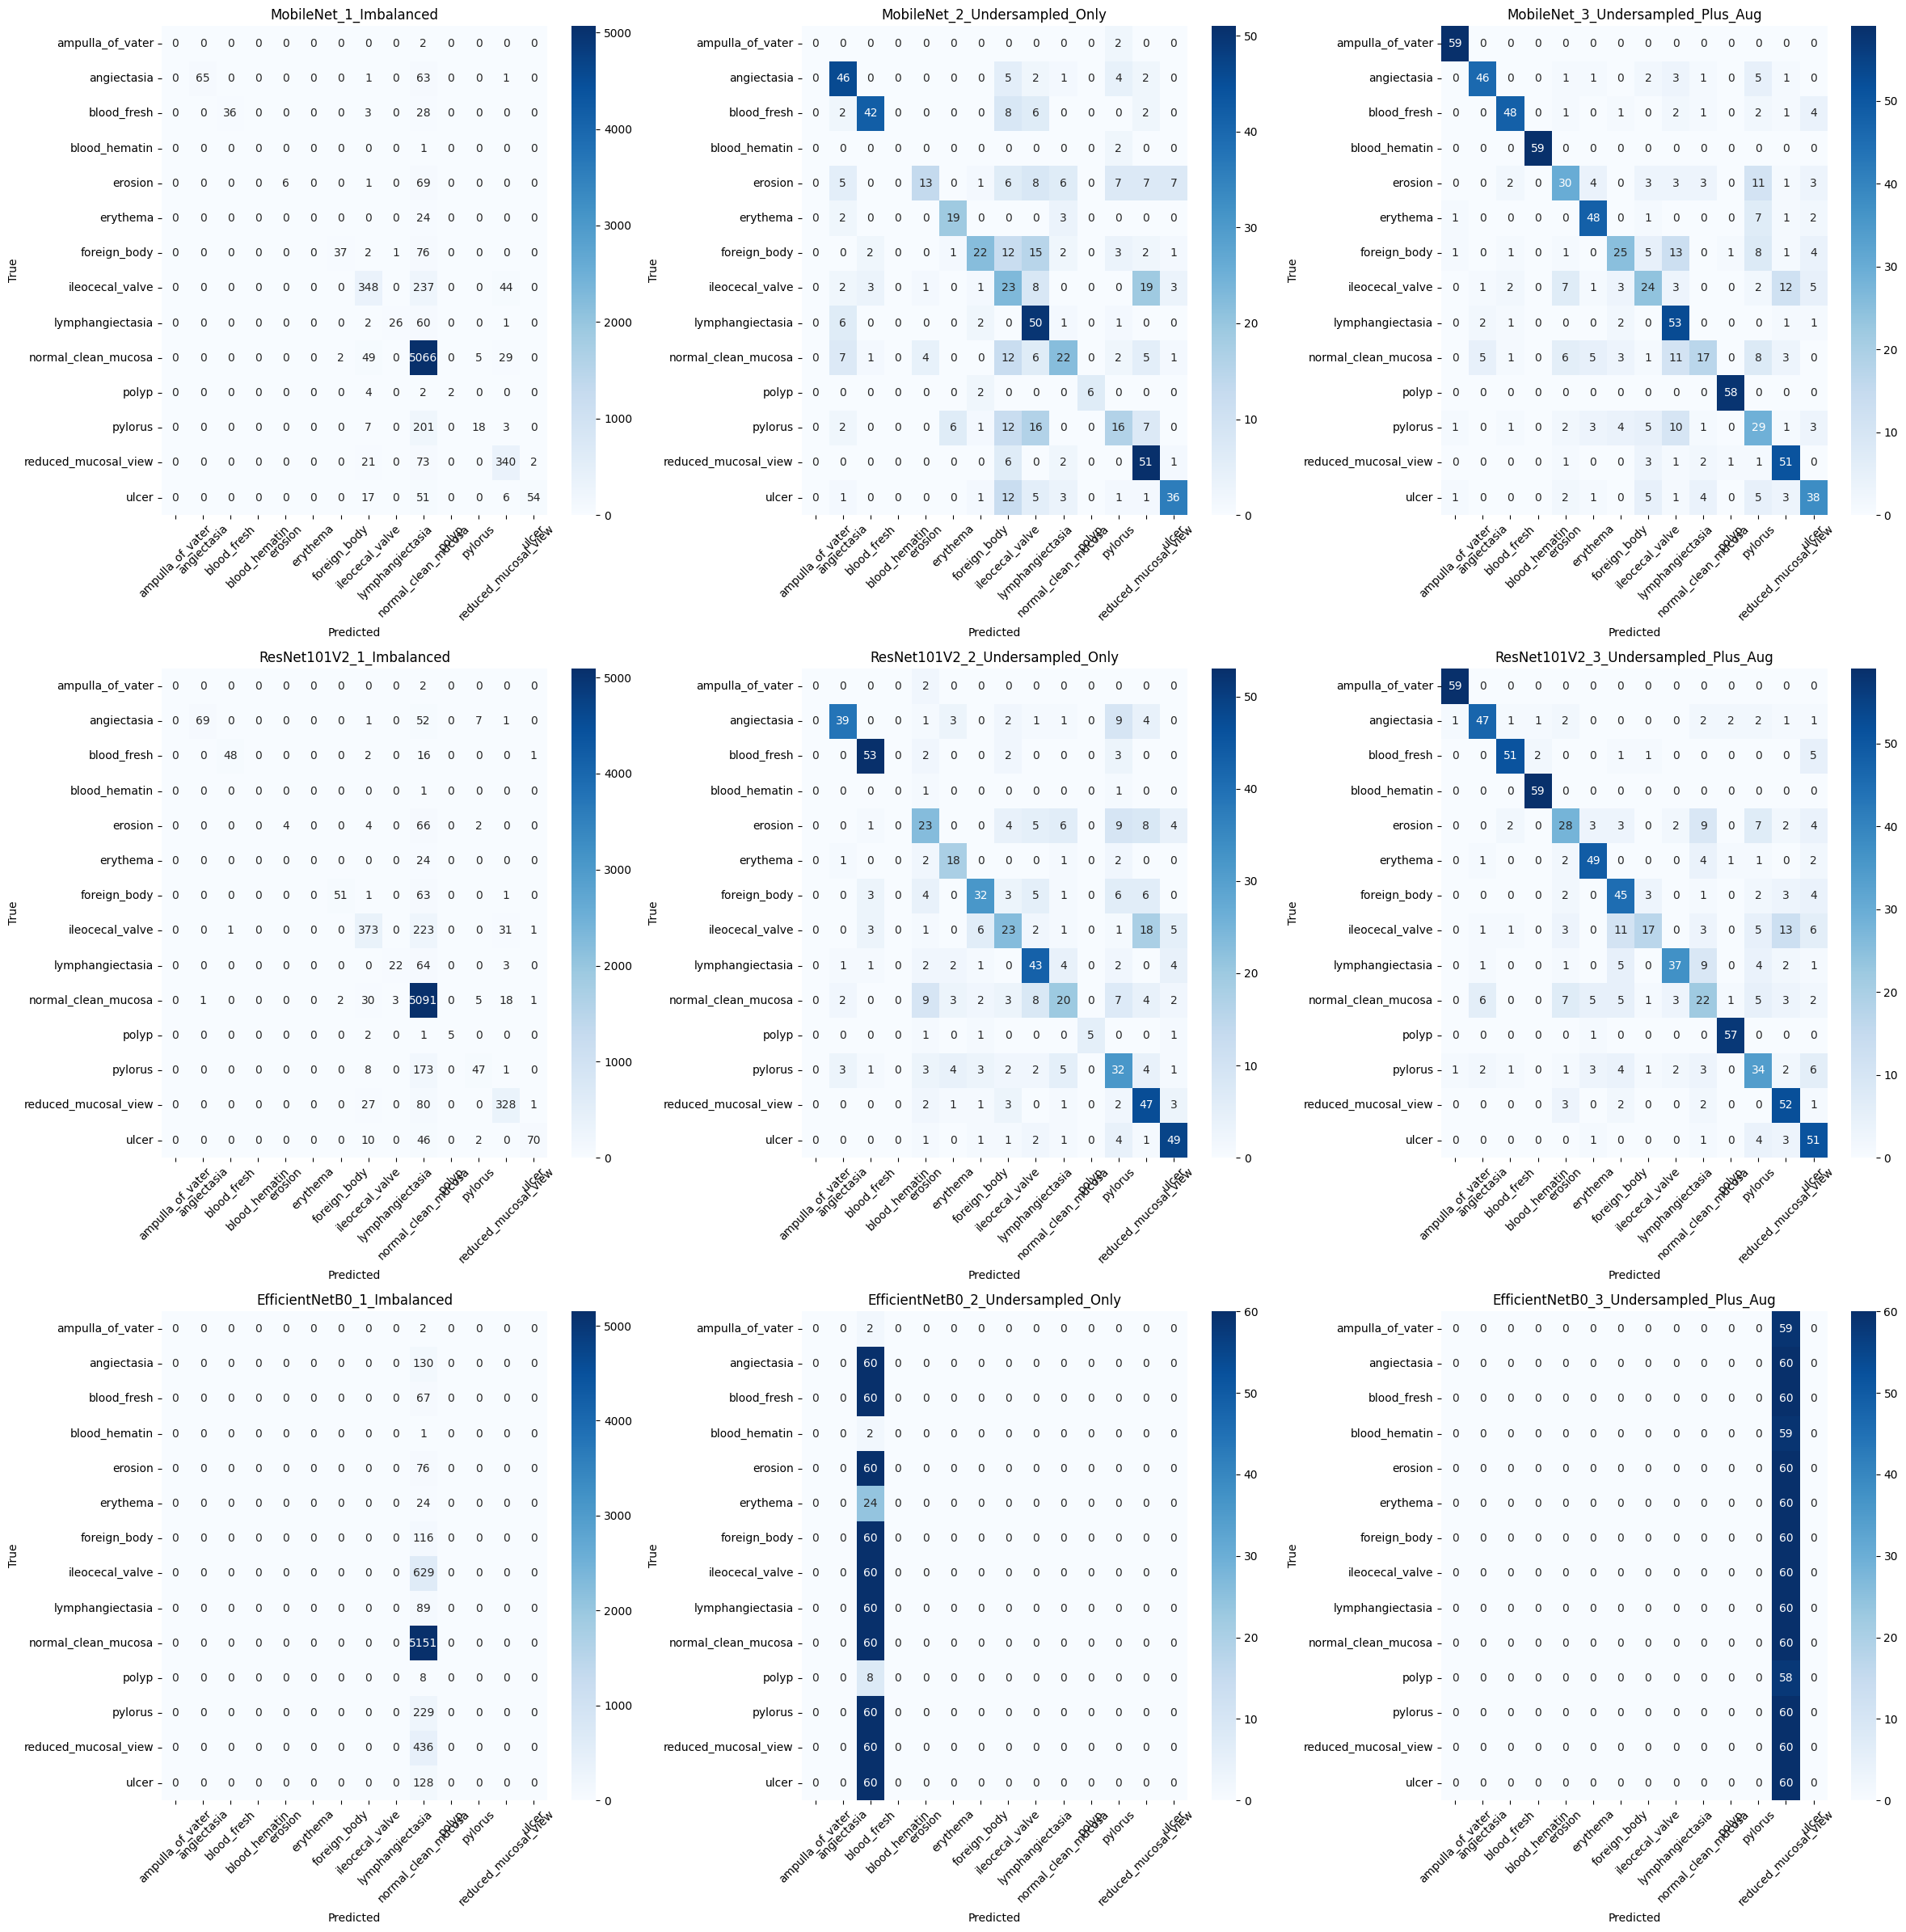

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(24, 24))
axes = axes.flatten()

for idx, (model_name, (cm, labels)) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=labels, yticklabels=labels)
    axes[idx].set_title(model_name)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Short Analysis
The evaluation reveals distinct behaviors across the three dataset settings. Training without imbalance handling produces high overall accuracy but exhibits poor minority class detection, heavily biasing predictions toward the majority classes. Applying under-sampling alone corrects this bias and improves macro-recall, but the severe data loss limits the models' ability to generalize, often reducing precision. The combination of under-sampling and augmentation yields the most balanced performance across all metrics. It allows the networks to learn robust features without collapsing into majority-class predictions. Among the architectures, EfficientNetB0 consistently shows the best trade-off between parameter efficiency and discriminative capability on the augmented data, whereas the heavier ResNet101V2 shows tendencies to overfit when data is strictly under-sampled.